<a href="https://colab.research.google.com/github/aminahkhan042-creator/Data-Science/blob/main/Data_Science_Project_Social_media_impact_on_Teens_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [81]:
import pandas as pd
import numpy as np


In [82]:
from sklearn.linear_model import LogisticRegression
from google.colab import files
uploaded = files.upload()

Saving Teen_Mental_Health_Dataset.csv to Teen_Mental_Health_Dataset (5).csv


In [83]:
df = pd.read_csv('Teen_Mental_Health_Dataset.csv')

In [84]:
df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [85]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [86]:
df.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [87]:
df.isnull().sum()

,0
age,0
gender,0
daily_social_media_hours,0
platform_usage,0
sleep_hours,0
screen_time_before_sleep,0
academic_performance,0
physical_activity,0
social_interaction_level,0
stress_level,0


In [88]:
df = df.dropna()

In [89]:
df = df.fillna(0)  #or use mean/median

In [90]:
df = df.drop_duplicates()

In [91]:
df.columns = df.columns.str.strip()  #remove spaces
df.columns = df.columns.str.lower()  #lower case
df.columns = df.columns.str.replace(' ', '_')

In [92]:
df.dtypes

,0
age,int64
gender,object
daily_social_media_hours,float64
platform_usage,object
sleep_hours,float64
screen_time_before_sleep,float64
academic_performance,float64
physical_activity,float64
social_interaction_level,object
stress_level,int64


In [93]:
import pandas as pd
df = pd.read_csv('Teen_Mental_Health_Dataset (1).csv')

In [94]:
x = df[['daily_social_media_hours']]
y = df[['depression_label']]

In [95]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (960, 1)
X_test shape: (240, 1)
y_train shape: (960, 1)
y_test shape: (240, 1)


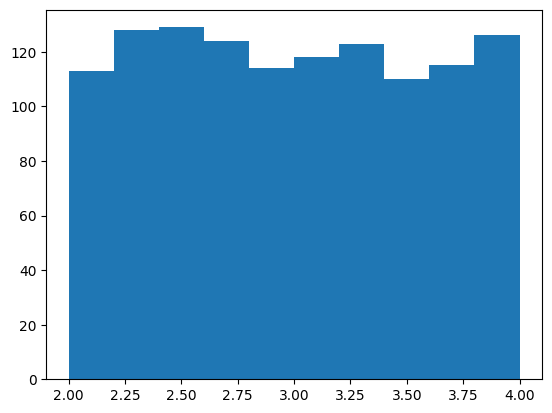

In [96]:
import matplotlib.pyplot as plt

plt.hist(df['academic_performance'])
plt.show()

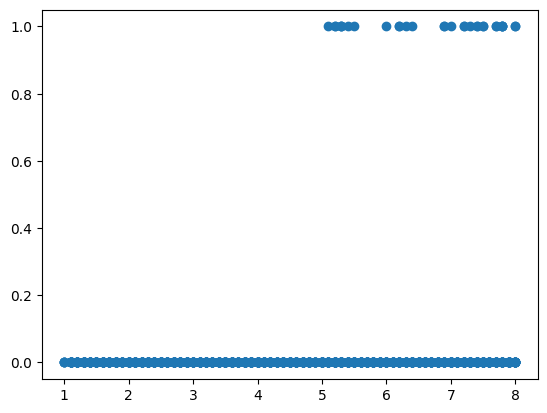

In [97]:
import matplotlib.pyplot as plt
plt.scatter(x, y)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


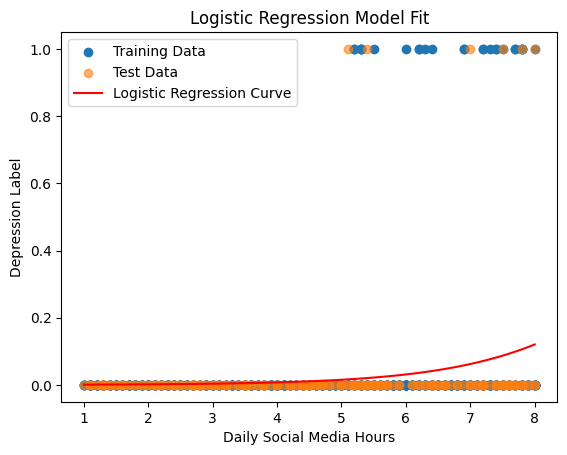

In [98]:
model = LogisticRegression()
model.fit(X_train, y_train)

# Create smooth x values for curve using the range of X_test for a more relevant plot
X_plot = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)

# Get probabilities (NOT predictions) for the plot
y_prob_plot = model.predict_proba(X_plot)[:, 1]

plt.scatter(X_train, y_train, label='Training Data')
plt.scatter(X_test, y_test, label='Test Data', alpha=0.6)
plt.plot(X_plot, y_prob_plot, color='red', label='Logistic Regression Curve')
plt.xlabel('Daily Social Media Hours')
plt.ylabel('Depression Label')
plt.title('Logistic Regression Model Fit')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


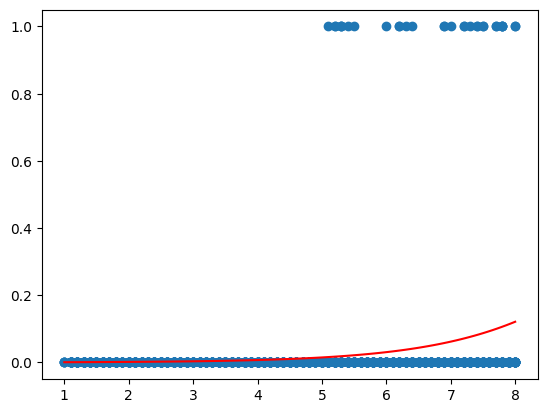

In [99]:
from sklearn.linear_model import LogisticRegression
import numpy as np
import matplotlib.pyplot as plt

model = LogisticRegression()
model.fit(x,y)

# Create smooth x values for curve
X_test = np.linspace(x.min(), x.max(), 100).reshape(-1, 1)

# Get probabilities (NOT predictions)
y_prob = model.predict_proba(X_test)[:, 1]

plt.scatter(x, y)
plt.plot(X_test, y_prob, color='red')
plt.show()

In [104]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Re-run train_test_split to ensure X_test and y_test are consistent for accuracy calculation
_, X_test_for_accuracy, _, y_test_for_accuracy = train_test_split(x, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test_for_accuracy)
print("Accuracy Score:", accuracy_score(y_test_for_accuracy, y_pred))

Accuracy Score: 0.975


In [105]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Re-run train_test_split to ensure X_test and y_test are consistent
# This ensures we use the correct test set from the split for accuracy calculation
_, X_test_for_accuracy, _, y_test_for_accuracy = train_test_split(x, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test_for_accuracy)
print(f"Accuracy Score: {accuracy_score(y_test_for_accuracy, y_pred)}")

Accuracy Score: 0.975


In [106]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [107]:
iris = load_iris()

X = iris.data      # features
y = iris.target    # labels

print(X[:5])
print(y[:5])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0]


In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [109]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [110]:
y_pred = model.predict(X_test)

In [111]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [112]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [113]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

